In [57]:
import seaborn as sns
tips = sns.load_dataset("tips")

In [60]:
display(tips.head())

display(tips.info())

display(tips.isnull().sum())

display(tips.describe())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


None

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


total_bill: Toplam hesap tutarı

tip: Bahşiş miktarı

sex: Cinsiyet (erkek/kadın)

smoker: Sigara içen/ içmeyen

day: Gün (Thu, Fri, Sat, Sun)

time: Günün zamanı (Lunch/Dinner)

size: Masa büyüklüğü (kişi sayısı)

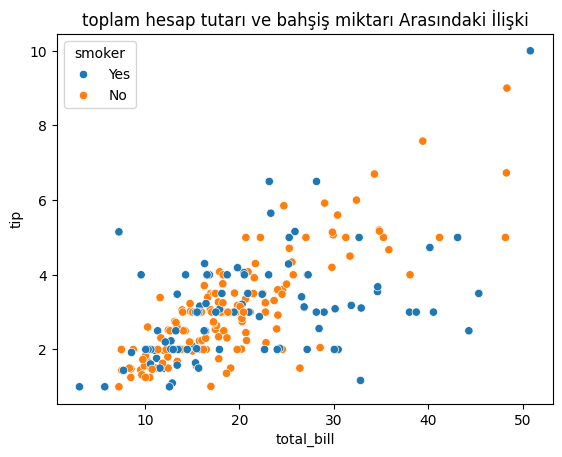

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
#1
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.title('toplam hesap tutarı ve bahşiş miktarı Arasındaki İlişki')
plt.show()

toplam hesap miktarı arttıkça bahşiş miktarı da artıyor. Ancak sigara, bahşiş miktarına doğrudan bir etki etmiyor

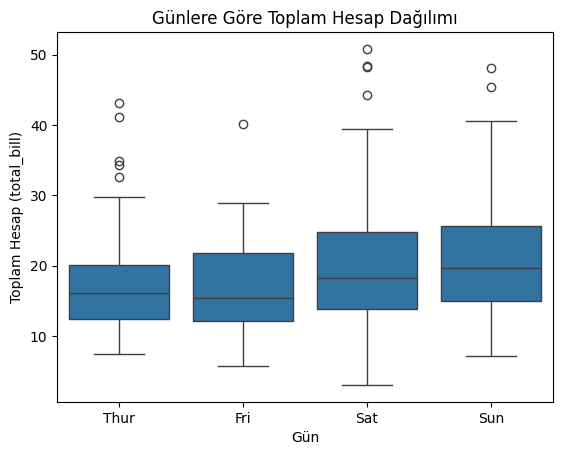

In [52]:
#2
sns.boxplot(data=tips, y='total_bill', x='day')
plt.title('Günlere Göre Toplam Hesap Dağılımı')
plt.xlabel('Gün')
plt.ylabel('Toplam Hesap (total_bill)')
plt.show()

perşembe günü aykırı değer en fazla gözüküyor. cumartesi pazar günü de toplam hesap tutarı en yüksek günler.(en fazla pazar günü)

<ipython-input-53-4f19f9d7ec69>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tips, x='size', y='tip_rate', ci=None, palette='pastel')
<ipython-input-53-4f19f9d7ec69>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='size', y='tip_rate', ci=None, palette='pastel')


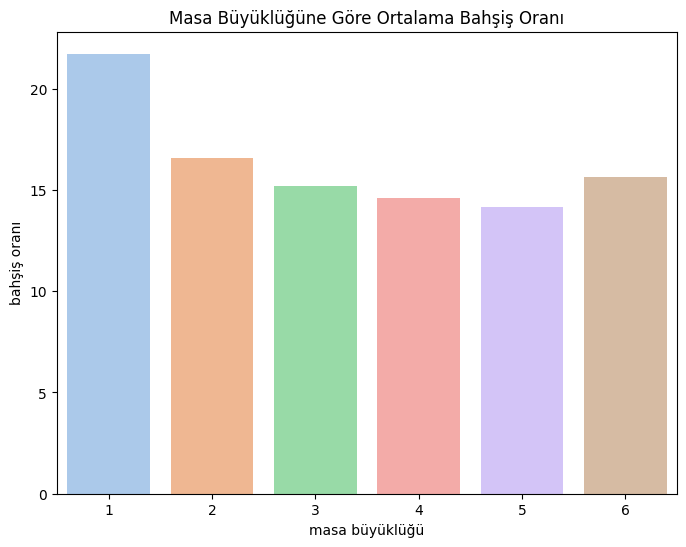

In [53]:
#3
tips['tip_rate'] = (tips['tip'] / tips['total_bill']) * 100


plt.figure(figsize=(8, 6))
sns.barplot(data=tips, x='size', y='tip_rate', ci=None, palette='pastel')
plt.title('Masa Büyüklüğüne Göre Ortalama Bahşiş Oranı')
plt.xlabel('masa büyüklüğü')
plt.ylabel('bahşiş oranı')
plt.show()


Genel olarak masa büyüklüğü arttıkça bahşiş oranı düşüyor. Ancak 5 kişilik masalarda bahşiş oranı, 4 ve 6 kişilik masalara göre biraz daha yüksek.

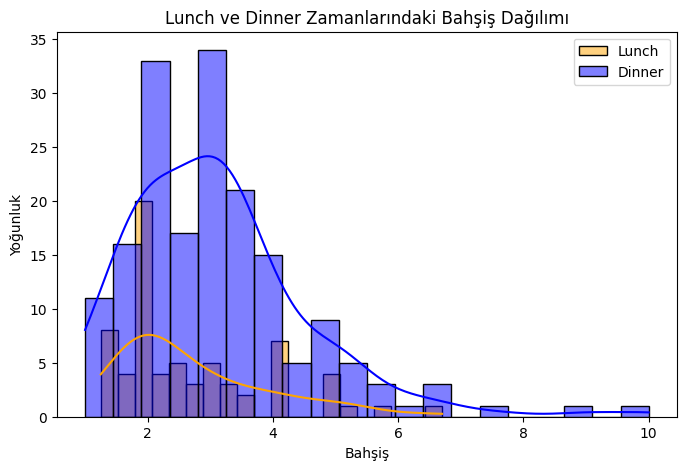

In [54]:
#4
plt.figure(figsize=(8, 5))
sns.histplot(tips[tips['time'] == 'Lunch']['tip'], bins=20, kde=True, color='orange', label='Lunch')
sns.histplot(tips[tips['time'] == 'Dinner']['tip'], bins=20, kde=True, color='blue', label='Dinner')
plt.title('Lunch ve Dinner Zamanlarındaki Bahşiş Dağılımı')
plt.xlabel('Bahşiş')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()


akşam saatlerinde bahşişler çok daha yüksek ve dağılım daha geniş. Ancak öğle yemeği daha dar alanda toplandığı için daha çok öngörülebilir

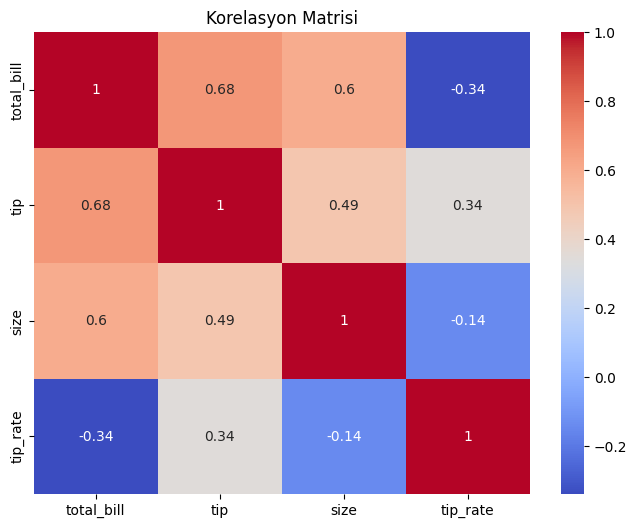

In [55]:
#5
# Sayısal sütunları seçme
numerical_tips = tips.select_dtypes(include=['number'])

# Korelasyon matrisi
corr = numerical_tips.corr()

# Heatmap ile korelasyon matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

toplam hesap ve bahşiş arasında güçlü bir korelasyon var yani biri artarken genellikle diğeri de artıyor. toplam hesap ve masa büyüklüğü arasında da güçlü bir korelasyon var. geri kalanı 0.5 ten daha düşük. Dolayısıyla güçlü bir korelasyon var diyemiyoruz